# E1 — The Agent Loop Without a Model

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Build the `observe → act → observe` loop that every 2026 agent framework implements — in plain Python, with **no language model anywhere in it**
- Write an explicit **JSON tool schema** and a validator that rejects a malformed call *before* it touches your data
- Make a tool fail on purpose, return the failure **as data** (not as an exception), and let the agent repair its own call and retry
- Measure what the surrounding machinery is worth: run the **same policy and the same tools** under three harnesses and compare the printed success rates

## 🔗 Where this fits

**Builds on:** Unit 1, lesson 04 `04_intelligent_agents_rationality.ipynb` — the `perceive → think → act` loop, sensors, actuators and the knowledge base of the smart-home agent. This notebook keeps that loop exactly and changes only *what the parts are made of*: the percepts arrive as JSON returned by tools, and the action is a tool call. Lesson 03 `03_python_basics_for_ai.ipynb` supplied the dictionaries and file I/O used below; lesson 12 `12_case_studies_intelligent_agents.ipynb` analysed deployed agents with PEAS — the harness table in Part 5 is the same analysis applied to the *plumbing* rather than to the agent.

**Used later in:** Course 02 (AIAT 112) Unit 5 `01_ai_learning_models.ipynb`, where a "learning model" is presented as a component inside a larger system; and Course 12 (AIAT 126) Unit 2 `01_system_design_architecture.ipynb`, where you draw the architecture of your own project — the tool boundary and the failure path you build here are two of the boxes in that diagram.

## 🌍 Why this matters: the model is not the system

Lesson 04 ended with a spacecraft. **Remote Agent** flew Deep Space 1 in 1999 with sensors, actuators and a
goal — and the fault that stopped it was not a fault of intelligence, it was a missing critical section in the
code *around* the intelligence. That sentence is now the organising idea of an entire subfield.

**The named case.** In October 2023 Jimenez, Yang, Wettig, Yao and colleagues released **SWE-bench**
([arXiv:2310.06770](https://arxiv.org/abs/2310.06770)): *"an evaluation framework consisting of 2,294 software
engineering problems drawn from real GitHub issues and corresponding pull requests across 12 popular Python
repositories."* A language model cannot even *attempt* one of those problems on its own. Something has to hand
it the repository, expose a way to read and edit files, run the test suite, feed the resulting error text back
in, and decide when to stop. That "something" is now called the **harness**, and the 2026 survey by Guo,
Hao, Wang and colleagues ([arXiv:2606.20683](https://arxiv.org/abs/2606.20683)) is built around the question
*"where does the bottleneck in agent performance reside, in the foundation model, in the execution harness, or
in the coupling between them?"*

**The uncomfortable number.** Li, Ko, Keramati and colleagues (August 2026,
[arXiv:2608.19741](https://arxiv.org/abs/2608.19741)) evaluated agents on stateful business workflows and
report their strongest model at **65.36 % pass@1** — but only **25.25 % pass^20**, i.e. the fraction of tasks it
completed on *twenty consecutive attempts*. Their title is the lesson: *One Success Isn't Reliability*.

**Why you can learn all of this today, offline.** The loop, the schema, the failure path and the retry policy
are **pure control flow**. They do not need a model to exist, and you understand them better without one,
because with a model in the middle every failure is ambiguous — was that the model or the harness? Here there
is no model, so the answer is never ambiguous. In Part 5 you will hold the "brain" fixed and change only the
harness, and the success rate will move by **half the task set**.

## 📥 Inputs & 📤 Outputs

**Inputs:** the repository's real **Titanic passenger manifest** (`load("titanic")`,
891 rows — the same file Course 04 uses), read from disk. Plus eight questions written in English. No network,
no API key, no model weights, no `pip install`.

**Outputs:** the printed JSON tool schema; a validator verdict on three example calls; the full step-by-step
trace of one task that needs **three** loop iterations to succeed; a per-task results table for three harnesses;
a comparison chart; and a step-budget sweep showing how many iterations each harness needs to be allowed.

## Part 1: The Environment — Two Tools Over One Real File

An agent's environment is whatever it can *observe* and *act on*. Ours is two functions:

| tool | what it does | what it can refuse |
|---|---|---|
| `passenger_stats(column, value)` | counts passengers in the manifest matching one column value and reports their survival rate | a column that is not in the file; a value that does not occur in that column |
| `calculator(expression)` | evaluates one arithmetic expression | division by zero |

Two design decisions in that table matter more than the tools themselves.

**1. A tool returns its failures as data.** Every call returns a dictionary with an `ok` flag. When something is
wrong, `ok` is `False` and the dictionary carries an `error` code and a `hint`. It does *not* raise. An exception
kills the loop; a returned error is just another observation the agent can act on. This is the single most
important line of engineering in the whole notebook.

**2. The hint is part of the contract.** `unknown_column` comes back with `did_you_mean`; `unknown_value` comes
back with the list of values that *do* exist. A tool that says only "error" gives the agent nothing to do next.

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("montgomery_911_calls"), ...
# -------------------------------------------------------------------------------------

In [2]:
# WHAT: load the real Titanic manifest and define the two tools our agent can call.
# WHY : the agent must act on something real. These are ordinary Python functions - the only unusual
#       thing about them is that they NEVER raise for a bad argument; they return a structured error
#       the agent can read, because an exception ends the loop and a returned error continues it.
import ast
import json
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd

# The shared loader locates the manifest whatever folder the kernel started in - and
# downloads it if this is a stray copy of the notebook with no repository around it.
# The whole 891-row file ships with the repository, so everyone reads the same 891 rows.
manifest = load("titanic")
MANIFEST_NAME = Path(manifest.attrs["path"]).name

# Fail loudly rather than agreeing with a truncated file - a silent 3-row dataset looks like a broken agent.
if len(manifest) != 891:
    raise RuntimeError(f"Expected the 891-row Titanic manifest, found {len(manifest)} rows.")

# A tiny "did you mean" table. Real tools build this from column metadata; ours is written out so you
# can see that the repair suggestion comes from the TOOL, not from anything clever in the agent.
COLUMN_ALIASES = {"class": "Pclass", "pclass": "Pclass", "gender": "Sex",
                  "sex": "Sex", "port": "Embarked", "embarked": "Embarked"}


def tool_passenger_stats(column: str, value: str) -> dict:
    """Count manifest rows where `column` equals `value`; report the count and the survival rate."""
    if column not in manifest.columns:
        return {"ok": False, "error": "unknown_column",
                "message": f"no column named {column!r} in the manifest",
                "hint": {"did_you_mean": COLUMN_ALIASES.get(column.lower()),
                         "columns": list(manifest.columns)}}
    as_text = manifest[column].astype(str)                       # compare everything as text
    present = sorted(as_text[manifest[column].notna()].unique().tolist())
    if value not in present:
        return {"ok": False, "error": "unknown_value",
                "message": f"{value!r} does not appear in column {column!r}",
                "hint": {"valid_values": present}}
    rows = manifest[as_text == value]
    return {"ok": True, "count": int(len(rows)),
            "survival_rate": round(float(rows["Survived"].mean()), 4)}


# Only these AST node types may appear in an expression: this is a calculator, not a Python interpreter.
ALLOWED_NODES = (ast.Expression, ast.BinOp, ast.UnaryOp, ast.Constant,
                 ast.Add, ast.Sub, ast.Mult, ast.Div, ast.USub, ast.UAdd)


def tool_calculator(expression: str) -> dict:
    """Evaluate one arithmetic expression. Raises on text it cannot parse - see Part 2 for why."""
    tree = ast.parse(expression, mode="eval")                    # SyntaxError on anything unparseable
    for node in ast.walk(tree):
        if not isinstance(node, ALLOWED_NODES):
            raise ValueError(f"{type(node).__name__} is not allowed in a calculator expression")
    try:
        value = eval(compile(tree, "<calc>", "eval"), {"__builtins__": {}})
    except ZeroDivisionError:
        return {"ok": False, "error": "math_error", "message": "division by zero", "hint": {}}
    return {"ok": True, "value": round(float(value), 4)}


TOOLS = {"passenger_stats": tool_passenger_stats, "calculator": tool_calculator}

print(f"Manifest: {MANIFEST_NAME}  ->  {len(manifest)} rows, {manifest.shape[1]} columns")
print(f"Tools available to the agent: {list(TOOLS)}\n")
print("A call that works :", tool_passenger_stats("Pclass", "1"))
print("A call that fails  :", tool_passenger_stats("class", "3")["error"],
      "->", tool_passenger_stats("class", "3")["hint"]["did_you_mean"])

titanic: full file, 891 rows.
Manifest: titanic.csv  ->  891 rows, 12 columns
Tools available to the agent: ['passenger_stats', 'calculator']

A call that works : {'ok': True, 'count': 216, 'survival_rate': 0.6296}
A call that fails  : unknown_column -> Pclass


## Part 2: The Tool Schema — the Contract, Written Down

A schema is a machine-readable description of *what a legal call looks like*: the tool's name, its arguments,
their types, and any pattern they must match. Every production agent stack ships one — OpenAI and Anthropic
function calling, and since 2025 the **Model Context Protocol** (Hou et al., [arXiv:2503.23278](https://arxiv.org/abs/2503.23278))
which standardised the same idea across vendors so that one tool server can serve any client.

It does two jobs, and only one of them is the obvious one.

- **It tells the caller what to say.** In a real agent this text is what the model reads to decide the call.
- **It tells the harness what to refuse.** The validator below checks a proposed call *before* execution. Notice
  what the schema can and cannot know: it knows `expression` must match `^[0-9+\-*/(). ]+$` — a fact about the
  *shape* of the call — but it cannot know that `Cherbourg` is not a value in the `Embarked` column, because
  that is a fact about *the world*. Shape errors belong to the validator; world errors belong to the tool.
  Confusing the two is how agents end up executing calls nobody checked.

In [3]:
# WHAT: write the tool schema as JSON, then a validator that decides whether a proposed call is legal.
# WHY : this is the boundary of the system. Everything upstream of it is a suggestion; everything
#       downstream of it runs against real data. The validator is ~20 lines and it is the only thing
#       standing between a malformed proposal and your file system.
TOOL_SCHEMA = [
    {
        "name": "passenger_stats",
        "description": ("Count passengers in the Titanic manifest whose `column` equals `value`, "
                        "and report how many of them survived."),
        "parameters": {
            "type": "object",
            "properties": {
                "column": {"type": "string", "description": "a column name exactly as written in the file"},
                "value": {"type": "string", "description": "the value to match, as text"},
            },
            "required": ["column", "value"],
        },
    },
    {
        "name": "calculator",
        "description": "Evaluate a single arithmetic expression over numbers.",
        "parameters": {
            "type": "object",
            "properties": {
                "expression": {"type": "string", "pattern": r"^[0-9+\-*/(). ]+$",
                               "description": "digits and + - * / ( ) . and spaces only"},
            },
            "required": ["expression"],
        },
    },
]
SCHEMA_BY_NAME = {t["name"]: t for t in TOOL_SCHEMA}


def validate_call(call: dict) -> dict:
    """Structural check only: does this call match the schema? Returns the same {ok, error, hint} shape."""
    if call["tool"] not in SCHEMA_BY_NAME:
        return {"ok": False, "error": "unknown_tool", "message": call["tool"],
                "hint": {"tools": list(SCHEMA_BY_NAME)}}
    spec = SCHEMA_BY_NAME[call["tool"]]["parameters"]
    args = call["args"]
    for required in spec["required"]:                     # every declared argument must be present
        if required not in args:
            return {"ok": False, "error": "missing_argument", "message": required, "hint": {}}
    for name, supplied in args.items():
        if name not in spec["properties"]:                # and no undeclared argument may sneak through
            return {"ok": False, "error": "unknown_argument", "message": name,
                    "hint": {"allowed": list(spec["properties"])}}
        prop = spec["properties"][name]
        if prop["type"] == "string" and not isinstance(supplied, str):
            return {"ok": False, "error": "wrong_type", "message": f"{name} must be a string", "hint": {}}
        if "pattern" in prop and not re.fullmatch(prop["pattern"], supplied):
            return {"ok": False, "error": "pattern_violation",
                    "message": f"{name}={supplied!r} contains characters the schema forbids",
                    "hint": {"pattern": prop["pattern"]}}
    return {"ok": True}


print("THE SCHEMA THE AGENT IS GIVEN\n" + "=" * 78)
print(json.dumps(TOOL_SCHEMA, indent=2)[:900] + "\n  ... (second tool omitted for space)\n")

print("THE VALIDATOR AT WORK\n" + "=" * 78)
for example in [
    {"tool": "passenger_stats", "args": {"column": "Pclass", "value": "3"}},   # legal
    {"tool": "calculator", "args": {"expression": "342 / 891 * 100%"}},        # illegal SHAPE: '%'
    {"tool": "passenger_stats", "args": {"column": "Embarked", "value": "Cherbourg"}},  # legal shape, wrong world
]:
    verdict = validate_call(example)
    print(f"  {str(verdict['ok']):5}  {json.dumps(example)}")
    if not verdict["ok"]:
        print(f"         -> {verdict['error']}: {verdict['message']}")
print("\nThe third call is SHAPE-legal and WORLD-wrong. Only the tool can catch that one.")

THE SCHEMA THE AGENT IS GIVEN
[
  {
    "name": "passenger_stats",
    "description": "Count passengers in the Titanic manifest whose `column` equals `value`, and report how many of them survived.",
    "parameters": {
      "type": "object",
      "properties": {
        "column": {
          "type": "string",
          "description": "a column name exactly as written in the file"
        },
        "value": {
          "type": "string",
          "description": "the value to match, as text"
        }
      },
      "required": [
        "column",
        "value"
      ]
    }
  },
  {
    "name": "calculator",
    "description": "Evaluate a single arithmetic expression over numbers.",
    "parameters": {
      "type": "object",
      "properties": {
        "expression": {
          "type": "string",
          "pattern": "^[0-9+\\-*/(). ]+$",
          "description": "digits and + - * / ( ) . and spaces only"
     
  ... (second tool omitted for space)

THE VALIDATOR AT WORK
  True  

## Part 3: The Policy — the Only Place a Model Would Go

In a 2026 agent, one function reads the task plus the history so far and returns the next tool call. That
function is a language model. Here it is twelve regular expressions.

Everything else in this notebook — the schema, the validator, the loop, the error contract, the retry, the step
limit — is **identical** to what a real system needs. That is the point of the exercise: swapping the twelve
regexes for a 70-billion-parameter model changes one function and nothing else.

Our policy is also **deliberately imperfect**, in exactly the way real policies are. It proposes `"class"` when
the file says `Pclass`, `"women"` when the file says `female`, `"Cherbourg"` when the file says `C`, and writes
a percent sign into an arithmetic expression. These are not typos — they are what a plausible-sounding wrong
answer looks like. Handling them is the harness's job, not the policy's.

In [4]:
# WHAT: the "brain" - a rule table that maps a question to a proposed tool call, plus a repair rule
#       that rewrites a call after reading an error observation.
# WHY : keeping the policy dumb and deterministic means every result later in this notebook is caused
#       by the harness, never by a lucky sample. Note that `repair` reads only the ERROR and the HINT -
#       it never looks at the dataset, so it cannot cheat its way to the answer.
RULES = [
    # (question pattern, proposed call, which field of the result answers the question)
    (r"third class",           {"tool": "passenger_stats", "args": {"column": "class", "value": "3"}}, "count"),
    (r"first class",           {"tool": "passenger_stats", "args": {"column": "Pclass", "value": "1"}}, "survival_rate"),
    (r"\bwomen\b",             {"tool": "passenger_stats", "args": {"column": "Sex", "value": "women"}}, "count"),
    (r"\bmale\b",              {"tool": "passenger_stats", "args": {"column": "Sex", "value": "male"}}, "count"),
    (r"cherbourg",             {"tool": "passenger_stats", "args": {"column": "port", "value": "Cherbourg"}}, "count"),
    (r"southampton",           {"tool": "passenger_stats", "args": {"column": "Embarked", "value": "S"}}, "survival_rate"),
    (r"percentage of the 891", {"tool": "calculator", "args": {"expression": "342 / 891 * 100%"}}, "value"),
    (r"did not survive",       {"tool": "calculator", "args": {"expression": "891 - 342"}}, "value"),
]
SYNONYMS = {"women": "female", "woman": "female", "men": "male", "man": "male"}


def propose(question: str):
    """First step of the loop: read the task, return a tool call and the result field that answers it."""
    for pattern, call, field in RULES:
        if re.search(pattern, question, flags=re.I):
            return json.loads(json.dumps(call)), field     # deep copy: never mutate the rule table
    return None, None


def repair(call: dict, observation: dict):
    """Later steps: read the error observation and rewrite the call. Returns None if it cannot."""
    call = json.loads(json.dumps(call))
    error = observation.get("error")
    if error == "unknown_column" and observation["hint"].get("did_you_mean"):
        call["args"]["column"] = observation["hint"]["did_you_mean"]          # use the tool's suggestion
        return call
    if error == "unknown_value":
        valid = observation["hint"]["valid_values"]
        proposed = call["args"]["value"]
        if SYNONYMS.get(proposed.lower()) in valid:                            # women -> female
            call["args"]["value"] = SYNONYMS[proposed.lower()]
            return call
        if proposed[:1].upper() in valid:                                      # Cherbourg -> C
            call["args"]["value"] = proposed[:1].upper()
            return call
    if error == "pattern_violation":
        call["args"]["expression"] = re.sub(r"[^0-9+\-*/(). ]", "", call["args"]["expression"])
        return call
    return None


TASKS = [
    "How many passengers travelled in third class?",
    "What share of first class passengers survived?",
    "How many women were on board?",
    "How many male passengers were on board?",
    "How many passengers boarded at Cherbourg?",
    "What share of passengers who boarded at Southampton survived?",
    "342 of the 891 people aboard survived - what percentage of the 891 is that?",
    "Of the 891 people aboard, how many did not survive?",
]

print(f"{'task':<62} first proposal")
print("-" * 118)
for question in TASKS:
    call, field = propose(question)
    print(f"{question:<62} {json.dumps(call)}")

task                                                           first proposal
----------------------------------------------------------------------------------------------------------------------
How many passengers travelled in third class?                  {"tool": "passenger_stats", "args": {"column": "class", "value": "3"}}
What share of first class passengers survived?                 {"tool": "passenger_stats", "args": {"column": "Pclass", "value": "1"}}
How many women were on board?                                  {"tool": "passenger_stats", "args": {"column": "Sex", "value": "women"}}
How many male passengers were on board?                        {"tool": "passenger_stats", "args": {"column": "Sex", "value": "male"}}
How many passengers boarded at Cherbourg?                      {"tool": "passenger_stats", "args": {"column": "port", "value": "Cherbourg"}}
What share of passengers who boarded at Southampton survived?  {"tool": "passenger_stats", "args": {"column": "Embarked", 

## Part 4: The Loop

Here is the whole of agency, in five lines of pseudocode:

```
observation = none
repeat at most MAX_STEPS times:
    call = policy(task, observation)      # think
    if harness validates and the call is illegal: record it and (maybe) repair
    observation = execute(call)           # act, then observe the result
    if observation is a success: return the answer
```

Three of those clauses are **harness parameters**, not agent intelligence: *whether* we validate, *whether* we
repair and retry, and *how many* steps we allow. Part 5 turns each one on and measures it.

The trace printed below is the task that needs all three: the policy asks for a column that does not exist,
then for a value that does not exist, and only its third call succeeds.

In [5]:
# WHAT: the observe -> act -> observe loop, with the three harness switches made explicit.
# WHY : write it once, run it under different switch settings, and the difference in results is
#       attributable to the harness alone - the policy and the tools never change.
class Harness:
    """A harness is three decisions about what happens AROUND the policy."""

    def __init__(self, name, validate: bool, retry: bool, max_steps: int = 4):
        self.name, self.validate, self.retry, self.max_steps = name, validate, retry, max_steps


def run_agent(question: str, harness: Harness, verbose: bool = False) -> dict:
    """Run one task. Returns the answer (or None) plus everything we want to measure."""
    call, field = propose(question)
    log = {"answer": None, "tool_calls": 0, "steps": 0, "invalid_executed": 0,
           "crashed": False, "outcome": "no_rule"}
    if call is None:
        return log

    for step in range(1, harness.max_steps + 1):
        log["steps"] = step
        if verbose:
            print(f"  step {step}  THINK  -> {json.dumps(call)}")

        if harness.validate:                                   # ---- gate: check the SHAPE first
            verdict = validate_call(call)
            if not verdict["ok"]:
                if verbose:
                    print(f"          BLOCK  <- {verdict['error']}: {verdict['message']}")
                if not harness.retry:
                    log["outcome"] = "blocked"
                    return log
                repaired = repair(call, verdict)
                if repaired is None:
                    log["outcome"] = "unrepairable"
                    return log
                call = repaired
                continue                                       # a blocked call never reaches the tool
        else:
            if not validate_call(call)["ok"]:                  # measured, but not acted on
                log["invalid_executed"] += 1

        try:                                                   # ---- act
            observation = TOOLS[call["tool"]](**call["args"])
            log["tool_calls"] += 1
        except Exception as exc:                               # a raising tool ends the run
            log["crashed"], log["outcome"] = True, f"crash:{type(exc).__name__}"
            if verbose:
                print(f"          CRASH  <- {type(exc).__name__}")
            return log

        if verbose:
            print(f"          OBSERVE<- {json.dumps(observation)[:150]}")
        if observation["ok"]:                                  # ---- done
            log["answer"], log["outcome"] = observation[field], "answered"
            return log
        if not harness.retry:
            log["outcome"] = f"tool_error:{observation['error']}"
            return log
        repaired = repair(call, observation)                   # ---- observe the error, fix, go again
        if repaired is None:
            log["outcome"] = "unrepairable"
            return log
        call = repaired

    log["outcome"] = "step_limit"
    return log


full_harness = Harness("C  validation + retry", validate=True, retry=True, max_steps=4)
print(f"TASK: {TASKS[4]}\n")
result = run_agent(TASKS[4], full_harness, verbose=True)
print(f"\nfinal answer = {result['answer']}   outcome = {result['outcome']}   "
      f"steps = {result['steps']}   tool calls = {result['tool_calls']}")

TASK: How many passengers boarded at Cherbourg?

  step 1  THINK  -> {"tool": "passenger_stats", "args": {"column": "port", "value": "Cherbourg"}}
          OBSERVE<- {"ok": false, "error": "unknown_column", "message": "no column named 'port' in the manifest", "hint": {"did_you_mean": "Embarked", "columns": ["Passen
  step 2  THINK  -> {"tool": "passenger_stats", "args": {"column": "Embarked", "value": "Cherbourg"}}
          OBSERVE<- {"ok": false, "error": "unknown_value", "message": "'Cherbourg' does not appear in column 'Embarked'", "hint": {"valid_values": ["C", "Q", "S"]}}
  step 3  THINK  -> {"tool": "passenger_stats", "args": {"column": "Embarked", "value": "C"}}
          OBSERVE<- {"ok": true, "count": 168, "survival_rate": 0.5536}

final answer = 168   outcome = answered   steps = 3   tool calls = 3


## Part 5: The Experiment — Same Brain, Three Harnesses

Now the comparison this notebook exists for. **The policy is fixed. The tools are fixed. The tasks are fixed.**
We change one thing at a time in the machinery around them:

| harness | validate the call? | observe the error and retry? |
|---|---|---|
| **A — bare loop** | no | no |
| **B — + schema validation** | yes | no |
| **C — + validation and retry** | yes | yes (up to 4 steps) |

Three things are measured, because "accuracy" alone would hide the interesting half:

- **correct** — the final answer matches ground truth computed independently with pandas, straight from the file
- **invalid calls executed** — calls that did not match the schema and reached the tool anyway (a safety count)
- **crashes** — runs that ended in an unhandled exception

In [6]:
# WHAT: compute ground truth directly from the dataframe, then run all 8 tasks under all 3 harnesses.
# WHY : the agent must be graded against numbers it did not produce. These come from pandas, not from
#       any tool the agent can call, so "correct" is a check and not a claim.
GOLD = {
    TASKS[0]: int((manifest["Pclass"] == 3).sum()),
    TASKS[1]: round(float(manifest.loc[manifest["Pclass"] == 1, "Survived"].mean()), 4),
    TASKS[2]: int((manifest["Sex"] == "female").sum()),
    TASKS[3]: int((manifest["Sex"] == "male").sum()),
    TASKS[4]: int((manifest["Embarked"] == "C").sum()),
    TASKS[5]: round(float(manifest.loc[manifest["Embarked"] == "S", "Survived"].mean()), 4),
    TASKS[6]: round(342 / 891 * 100, 4),
    TASKS[7]: 891 - 342,
}
print("Ground truth, computed from the file with pandas:")
for question, gold in GOLD.items():
    print(f"  {gold:>10}   {question}")

HARNESSES = [
    Harness("A  bare loop", validate=False, retry=False),
    Harness("B  + schema validation", validate=True, retry=False),
    Harness("C  + validation + retry", validate=True, retry=True),
]

rows, summary = [], []
for harness in HARNESSES:
    correct = invalid = crashes = calls = 0
    for question in TASKS:
        log = run_agent(question, harness)
        hit = log["answer"] is not None and abs(log["answer"] - GOLD[question]) < 1e-3
        correct += hit
        invalid += log["invalid_executed"]
        crashes += log["crashed"]
        calls += log["tool_calls"]
        rows.append({"harness": harness.name[:1], "task": question[:44],
                     "answer": log["answer"], "gold": GOLD[question],
                     "correct": bool(hit), "outcome": log["outcome"]})
    summary.append({"harness": harness.name, "correct": f"{correct}/{len(TASKS)}",
                    "correct_frac": correct / len(TASKS), "invalid_calls_executed": invalid,
                    "crashes": crashes, "tool_calls": calls})

results = pd.DataFrame(rows)
print("\nPer-task outcome (A / B / C):\n")
pivot = results.pivot_table(index="task", columns="harness", values="outcome", aggfunc="first")
print(pivot.to_string())
print("\nSummary:\n")
print(pd.DataFrame(summary)[["harness", "correct", "invalid_calls_executed",
                             "crashes", "tool_calls"]].to_string(index=False))

Ground truth, computed from the file with pandas:
         491   How many passengers travelled in third class?
      0.6296   What share of first class passengers survived?
         314   How many women were on board?
         577   How many male passengers were on board?
         168   How many passengers boarded at Cherbourg?
       0.337   What share of passengers who boarded at Southampton survived?
     38.3838   342 of the 891 people aboard survived - what percentage of the 891 is that?
         549   Of the 891 people aboard, how many did not survive?

Per-task outcome (A / B / C):

harness                                                               A                          B         C
task                                                                                                        
342 of the 891 people aboard survived - what          crash:SyntaxError                    blocked  answered
How many male passengers were on board?                        answered     

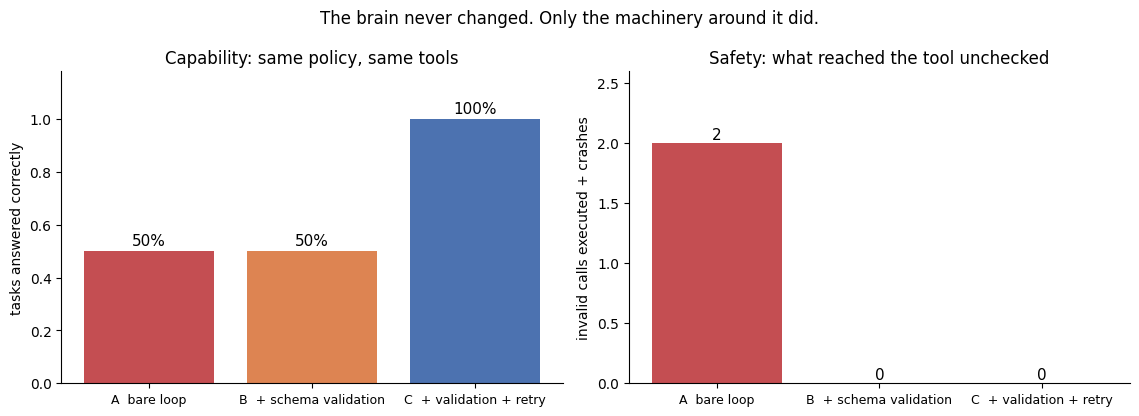

In [7]:
# WHAT: the same summary as a chart - capability on the left, safety on the right.
# WHY : the two panels move for different reasons, and a single "accuracy" bar would hide that.
import matplotlib.pyplot as plt   # the notebook's inline backend renders this into the page

summary_df = pd.DataFrame(summary)
labels = [h.name for h in HARNESSES]
colours = ["#C44E52", "#DD8452", "#4C72B0"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

axes[0].bar(labels, summary_df["correct_frac"], color=colours)
for x, frac in enumerate(summary_df["correct_frac"]):
    axes[0].text(x, frac + 0.02, f"{frac:.0%}", ha="center", fontsize=11)
axes[0].set_ylim(0, 1.18)
axes[0].set_ylabel("tasks answered correctly")
axes[0].set_title("Capability: same policy, same tools")

unsafe = summary_df["invalid_calls_executed"] + summary_df["crashes"]
axes[1].bar(labels, unsafe, color=colours)
for x, count in enumerate(unsafe):
    axes[1].text(x, count + 0.03, str(int(count)), ha="center", fontsize=11)
axes[1].set_ylim(0, max(2.4, unsafe.max() * 1.3))
axes[1].set_ylabel("invalid calls executed + crashes")
axes[1].set_title("Safety: what reached the tool unchecked")

for ax in axes:
    ax.tick_params(axis="x", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("The brain never changed. Only the machinery around it did.", fontsize=12)
plt.tight_layout()
plt.show()

## 📊 What these numbers actually support

Read the table and the chart together.

- **A → B changed nothing about capability and everything about safety.** Both answer **4 of 8** tasks. But A
  executed **1 call that did not match its own schema** and ended **1 run in an unhandled exception**; B executed
  **0** invalid calls and crashed **0** times. Validation is not an accuracy feature. It is the difference
  between a wrong answer and an unreviewed call running against your data.
- **B → C is where the accuracy came from: 4/8 → 8/8.** Every one of those four extra tasks was already
  *reachable* — the tools always held the answer. What was missing was a path from an error back into the loop.
- **It is not free.** C spent **12 tool calls** to answer 8 questions; A and B spent **7** each — A's malformed
  call crashed the run before a tool could return, and B's was blocked before it was sent. Retrying cost about
  **70 % more calls**, and in a real system every call is
  latency, money, and one more chance to act on the world. Course 02's enrichment lesson E9 measures that
  accuracy-for-compute trade as a curve.

**What these numbers do not support:** that "add a retry" is a general fix. Our repair function succeeds because
the tools return machine-readable hints and the mistakes are of a kind the hint can resolve. Change the policy's
error from `"port"` to a subtly wrong-but-valid column and every harness here returns a confident wrong answer,
because nothing raises. **A retry loop repairs errors that announce themselves. It does nothing about errors
that do not.**

In [8]:
# WHAT: sweep the step limit for harness C - the third harness parameter, on its own.
# WHY : "how many attempts is the agent allowed?" is a number someone types into a config file. Here you
#       can see exactly what each additional allowed step buys, and where the curve stops paying.
budget_rows = []
for max_steps in (1, 2, 3, 4, 5):
    harness = Harness("C", validate=True, retry=True, max_steps=max_steps)
    logs = [run_agent(question, harness) for question in TASKS]
    correct = sum(log["answer"] is not None and abs(log["answer"] - GOLD[q]) < 1e-3
                  for q, log in zip(TASKS, logs))
    budget_rows.append({"max_steps": max_steps, "correct": f"{correct}/{len(TASKS)}",
                        "accuracy": correct / len(TASKS),
                        "tool_calls": sum(log["tool_calls"] for log in logs)})

budget = pd.DataFrame(budget_rows)
print(budget.to_string(index=False))
print("\nThe step limit is a compute budget. Below the budget the task is simply unreachable;")
print("above it, extra steps buy nothing at all - the curve is flat, not rising.")

 max_steps correct  accuracy  tool_calls
         1     4/8     0.500           7
         2     7/8     0.875          11
         3     8/8     1.000          12
         4     8/8     1.000          12
         5     8/8     1.000          12



The step limit is a compute budget. Below the budget the task is simply unreachable;
above it, extra steps buy nothing at all - the curve is flat, not rising.


## 💬 Discuss

1. Harness B blocked the malformed call and then **gave up**. Harness C blocked it and **repaired** it. There is
   a third option nobody built here: block it and **ask a human**. For which of our eight tasks would you route
   to a human instead of retrying — and what property of the task decides that, given the agent cannot tell the
   difference between "I mistyped a column name" and "I am about to answer a question I have misunderstood"?
2. Our `repair` function reads only the error code and the hint, never the dataset. Suppose it *could* read the
   dataset, and a future version fixed `unknown_value` by picking the closest string match. Name a case where
   that is obviously right, and a case where it silently answers a different question than the one asked. Where
   does the boundary belong?
3. Li et al. reported 65.36 % pass@1 and 25.25 % pass^20 for the same agent on the same tasks. Our harness C
   scores 8/8, and it would score 8/8 a thousand times because nothing here is random. **Is that a strength of
   this lesson or a weakness of it?** What would you have to add to make our number as honest as theirs?

## ✅ Summary

**What you built and measured** (every number above was printed by the cells, not asserted):

- An `observe → act → observe` loop with **no model in it** — the same loop lesson 04 called
  `perceive → think → act`, with percepts arriving as JSON from tools
- An explicit **JSON tool schema** and a validator that separates *shape* errors (which the schema can see) from
  *world* errors (which only the tool can see)
- Two tools over the real 891-row Titanic manifest that **return failures as data**, with hints an agent can act on
- One task requiring **three** loop iterations: unknown column → unknown value → answer
- A controlled comparison: the same policy and tools scored **4/8, 4/8, 8/8** under three harnesses, with **1**
  invalid call executed and **1** crash in the bare loop and **0** of each once the validator was in place
- A step-budget sweep showing where extra attempts stop buying anything

**The one sentence to keep:** the model is the part everyone talks about, and the harness — schema, error
contract, retry, step limit — is the part that decided half our task set.

**Where this goes next:** replace `propose()` with a language model and you have a 2026 agent; everything else
in this notebook stays exactly where it is.

## ⚠️ Where this breaks

**There is no model, so there is no ambiguity — and real agents are ambiguous.** Our policy is deterministic:
same question, same call, every time. A model-driven policy is not. It can propose a different call on the
second run, succeed once and fail twice, and no amount of reading the code will tell you which. That is why
2026 practice reports **pass^k over repeated runs** rather than a single trace (Li et al., 2026), and why our
perfect 8/8 is a statement about a rule table, not evidence about agents.

**Our tasks are read-only, and that is what makes retrying safe.** `passenger_stats` cannot change anything, so
a wrong call costs nothing and trying again is free. Give an agent a tool that sends an email, issues a refund,
or deletes a row, and "just retry" becomes "do it twice". Real harnesses split tools into reversible and
irreversible, and only the reversible half is allowed a retry loop.

**The tool boundary is a security boundary, and we only defended its shape.** Our validator checks types and
patterns. It has no opinion about *who* is asking or *what* the returned text says. When an observation comes
from a document, a web page or an email rather than a CSV, hostile text inside that observation is read by the
policy as if it were an instruction — the indirect prompt injection problem, and the reason MCP's own reference
paper is subtitled *Landscape, Security Threats, and Future Research Directions* (Hou et al., 2025). Course 06
Unit 3's enrichment lesson `E3_prompt_injection_sandbox.ipynb` builds that attack and then blocks it.

**A repair loop can loop.** Ours terminates because `repair` returns `None` when it has nothing to try. Remove
that and cap `max_steps` at 50 and you get the classic failure: an agent making the same rejected call fifty
times, spending real money each time. The step limit is not a performance tuning knob; it is the thing standing
between you and an unbounded bill.

**Eight tasks is a demonstration, not an evaluation.** Each task is worth 12.5 percentage points. The gap
between B and C is four tasks and it is large enough to read; a gap of one task would not have been.

## 📚 References

The loop, the tool contract, and the 2026 argument that the harness is where the engineering is:

1. Yao, S., Zhao, J., Yu, D., Du, N., Shafran, I., Narasimhan, K., & Cao, Y. (2022). *ReAct: Synergizing Reasoning and Acting in Language Models*. ICLR 2023. [arXiv:2210.03629](https://arxiv.org/abs/2210.03629) — the interleaved reason → act → observe loop this notebook implements without a model; reasoning traces "help the model induce, track, and update action plans as well as handle exceptions."
2. Schick, T., Dwivedi-Yu, J., Dessì, R., Raileanu, R., Lomeli, M., Zettlemoyer, L., et al. (2023). *Toolformer: Language Models Can Teach Themselves to Use Tools*. [arXiv:2302.04761](https://arxiv.org/abs/2302.04761) — established tool invocation as a model capability rather than a hand-written pipeline.
3. Jimenez, C. E., Yang, J., Wettig, A., Yao, S., Pei, K., Press, O., & Narasimhan, K. (2023). *SWE-bench: Can Language Models Resolve Real-World GitHub Issues?* [arXiv:2310.06770](https://arxiv.org/abs/2310.06770) — 2,294 problems from real GitHub issues across 12 Python repositories; the benchmark that made the harness unavoidable.
4. Hou, X., Zhao, Y., Wang, S., & Wang, H. (2025). *Model Context Protocol (MCP): Landscape, Security Threats, and Future Research Directions*. [arXiv:2503.23278](https://arxiv.org/abs/2503.23278) — the standardised version of the tool schema in Part 2, and a taxonomy of 16 threat scenarios that come with it.
5. Guo, J., Hao, Z., Wang, C., Fan, C., Luo, T., Li, H., et al. (2026). *From Question Answering to Task Completion: A Survey on Agent System and Harness Design*. [arXiv:2606.20683](https://arxiv.org/abs/2606.20683) — asks "where does the bottleneck in agent performance reside, in the foundation model, in the execution harness, or in the coupling between them?" and decomposes the harness into runtime responsibilities.
6. Li, Z., Ko, Y., Keramati, A., Ferri, N., Palmaz Lopez Pelaez, S., Tsai, L.-C., et al. (2026). *One Success Isn't Reliability: Thinkingbox, a Sandbox and Benchmark for Agents in Stateful Business Workflows*. [arXiv:2608.19741](https://arxiv.org/abs/2608.19741) — 65.36 % pass@1 against 25.25 % pass^20 for the same agent; the honest way to report agent results.